In [143]:
# -- used librarys
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from scipy import stats

from IPython.display import display

from oemof.demand import bdew

import datetime

import pvlib
from pvlib.modelchain import ModelChain as Mc_Pva
from pvlib.location import Location 
from pvlib.pvsystem import PVSystem
from pvlib.solarposition import get_solarposition
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

import pyomo.environ as pyo
from pyomo.opt import SolverFactory

## Load profile generation

In [144]:
# -- load profile
# 
E_el_commercial = 0.45e12 # = 0.45 TWh
E_el_agriculture = 0.15e12 # = 0.15 TWh
E_el_households = 0.4e12 # = 0.4 TWh

# load profiles
dict_demand_year = {}

for year in range(2020, 2050):
    holidays = {
        datetime.date(year, 1, 1): "New Year's Day",
        datetime.date(year, 4, 10): "Good Friday", # inaccuracy for years beside 2020 are neglectable
        datetime.date(year, 4, 13): "Easter Monday", # inaccuracy for years beside 2020 are neglectable
        datetime.date(year, 5, 1): "Labour Day",
        datetime.date(year, 5, 21): "Ascension Day", # inaccuracy for years beside 2020 are neglectable
        datetime.date(year, 6, 1): "Whit Monday", # inaccuracy for years beside 2020 are neglectable
        datetime.date(year, 10, 3): "German Unity Day",
        datetime.date(year, 12, 25): "Christmas Day",
        datetime.date(year, 12, 26): "Boxing Day",
    } # for variance in load profile

    e_slp = bdew.ElecSlp(year, holidays=holidays)
    df_load_commercial = e_slp.get_scaled_power_profiles({"g0": E_el_commercial})
    df_load_agriculture = e_slp.get_scaled_power_profiles({"l0": E_el_agriculture})
    df_load_households = e_slp.get_scaled_power_profiles({"h0": E_el_households})
    dict_demand_year[year] = (df_load_commercial["g0"] + df_load_agriculture["l0"] + df_load_households["h0"]).resample('1h').mean()

series_load = pd.concat(dict_demand_year.values())

In [145]:
series_load

2020-01-01 00:00:00    6.776355e+07
2020-01-01 01:00:00    5.519497e+07
2020-01-01 02:00:00    4.732290e+07
2020-01-01 03:00:00    4.382982e+07
2020-01-01 04:00:00    4.262382e+07
                           ...     
2049-12-31 19:00:00    1.618889e+08
2049-12-31 20:00:00    1.363771e+08
2049-12-31 21:00:00    1.121759e+08
2049-12-31 22:00:00    9.561406e+07
2049-12-31 23:00:00    7.868184e+07
Freq: h, Length: 262992, dtype: float64

## Weather data import

In [146]:
# -- meta data
# north
df_meta_north = pd.read_csv("./Nord 00591/Metadaten.txt", sep=";", skipinitialspace=True, skipfooter=1, engine="python", encoding="latin1")
height_station_north = float(df_meta_north.iloc[-1,4])
latlon_north = [float(df_meta_north.iloc[-1,3]), float(df_meta_north.iloc[-1,2])]
# south
df_meta_south = pd.read_csv("./Süd 05404/Metadaten.txt", sep=";", skipinitialspace=True, skipfooter=1, engine="python", encoding="latin1")
height_station_south = float(df_meta_south.iloc[-1,4]) 
latlon_south = [float(df_meta_south.iloc[-1,3]), float(df_meta_south.iloc[-1,2])]
# center
df_meta_center = pd.read_csv("./Zentrum 03231/Metadaten.txt", sep=";", skipinitialspace=True, skipfooter=1, engine="python", encoding="latin1")
height_station_center = float(df_meta_center.iloc[-1,4]) 
latlon_center = [float(df_meta_center.iloc[-1,3]), float(df_meta_center.iloc[-1,2])]

# list with meta data
list_latlons = [latlon_north, latlon_south, latlon_center]
list_heights_station = [height_station_north, height_station_south, height_station_center]

In [147]:
# -- weather data set north
# import data for irradiance in J/(cm^2)
df_solar_north = pd.read_csv("./Nord 00591/solar.txt", sep=";", skipinitialspace=True, engine="python")
df_solar_north = df_solar_north.drop(columns=["STATIONS_ID", "QN", "SD_10", "LS_10", "eor"])
# import data for air temperature at 2 m above ground level in °C
df_temperature_north = pd.read_csv("./Nord 00591/temperatur.txt", sep=";", skipinitialspace=True, engine="python")
df_temperature_north = df_temperature_north.drop(columns=["MESS_DATUM", "STATIONS_ID", "QN", "TM5_10", "RF_10", "TD_10", "eor"])
# combine
df_north = df_solar_north.join(df_temperature_north, how="outer")

In [148]:
# -- weather data set south
# import data for irradiance in J/(cm^2)
df_solar_south = pd.read_csv("./Süd 05404/solar.txt", sep=";", skipinitialspace=True, engine="python")
df_solar_south = df_solar_south.drop(columns=["STATIONS_ID", "QN", "SD_10", "LS_10", "eor"])
# import data for air temperature at 2 m above ground level in °C
df_temperature_south = pd.read_csv("./Süd 05404/temperatur.txt", sep=";", skipinitialspace=True, engine="python")
df_temperature_south = df_temperature_south.drop(columns=["MESS_DATUM", "STATIONS_ID", "QN", "TM5_10", "RF_10", "TD_10", "eor"])
# combine
df_south = df_solar_south.join(df_temperature_south, how="outer")

In [149]:
# -- weather data set center
# import data for irradiance in J/(cm^2)
df_solar_center = pd.read_csv("./Zentrum 03231/solar.txt", sep=";", skipinitialspace=True, engine="python")
df_solar_center = df_solar_center.drop(columns=["STATIONS_ID", "QN", "SD_10", "LS_10", "eor"])
# import data for air temperature at 2 m above ground level in °C
df_temperature_center = pd.read_csv("./Zentrum 03231/temperatur.txt", sep=";", skipinitialspace=True, engine="python")
df_temperature_center = df_temperature_center.drop(columns=["MESS_DATUM", "STATIONS_ID", "QN", "TM5_10", "RF_10", "TD_10", "eor"])
# combine
df_center = df_solar_center.join(df_temperature_center, how="outer")

In [150]:
# -- data cleaning - replacing error value -999 with average value at the same time of other years
dict_error = {}
list_str_location = ["North", "South", "Center"]
indexdiff_one_year = 6 * 24 * 365 # number of indices per year - leap year neglected, since shift of 10 minutes has only small influence
list_df_location = [df_north, df_south, df_center] # temporary list for iteration, will be overwritten at the end of the loop
list_years = ["2020", "2021", "2022", "2023", "2024"] # cleaning for each year, based on the other years
list_colnames = df_north.columns.astype(str)[1:] # north is used here, but the column names apply to all stations
for i, df_location in enumerate(list_df_location): # iteration through all location
    dict_error_measurement = {}
    for measurement in list_colnames: # iteration through all measured values (solar - global and diffuse irradiance, temperature, pressure)
        counter_error_measurement = 0
        for index in range(df_location.shape[0]): # for each index (i.e. each timestamp)
            if df_location.loc[index, measurement] == -999: # all entries that have error value -999
                counter_error_measurement += 1
                year_diff = 0 # correction value that sets the comparison years relative to the current year
                for year in list_years: 
                    if str(df_location.iloc[index, 0])[:4] == year: # filter to the respective year for specific application
                        list_compare_value = [] # comparison values at the same time from the other years are inserted here
                        list_manipulated_compare_factors = [(0-year_diff), (1-year_diff), (2-year_diff), (3-year_diff), (4-year_diff)] # i.e. in 2022: [-2, -1, 0, 1, 2]
                        for compare_factor in list_manipulated_compare_factors: # numbers in list represent annual distance, e.g. -1 => 1 year in the past, 2 => 2 years in the future
                            if df_location.loc[(index + indexdiff_one_year * compare_factor), measurement] != -999: # filtering comparison values without error value
                                list_compare_value.append(df_location.loc[(index + indexdiff_one_year * compare_factor), measurement])
                        df_location.loc[index, measurement] = np.mean(list_compare_value) # replace error value with average of comparison values
                    year_diff += 1
        dict_error_measurement[measurement] = counter_error_measurement
    dict_error[list_str_location[i]] = dict_error_measurement
    # renaming
    df_location["MESS_DATUM"] = pd.to_datetime(df_location["MESS_DATUM"], format="%Y%m%d%H%M") # read timestamp correctly
    df_location = df_location.rename(
        columns={"DS_10": "dhi", "GS_10": "ghi", "TT_10": "temp_air", "PP_10": "pressure"}
    )
    df_location = df_location.set_index("MESS_DATUM")
    df_location.index.name = None
    # units
    df_location["ghi"] *= (10000 / 600) # Conversion factor from J/(cm² * 10min) to avg W/(m²)
    df_location["dhi"] *= (10000 / 600) # Conversion factor from J/(cm² * 10min) to avg W/(m²)
    df_location["pressure"] *= 100 # Conversion factor hPa to Pa
    df_location["Ø global irradiance [kWh/(m²a)]"] = df_location["ghi"] * 8.76 # Conversion factor from W/(m²) to kWh/(m²a)
    # overwrites the element in the list that stores the data frames
    df_location = df_location.resample("h").mean()
    list_df_location[i] = df_location

# vizualisation for missing values in the weather data sets    
df_error = pd.DataFrame(dict_error)
df_error = df_error.rename(index={
    "DS_10": "diffuse horizontal irradiance",
    "GS_10": "global horizontal irradiance",
    "PP_10": "ambient pressure",
    "TT_10": "temperature at 2 m AGL" # above ground level
})
df_error.index.name = "missing values in data set"
display(df_error)

,North,South,Center
missing values in data set,,,
diffuse horizontal irradiance,604,6909,505
global horizontal irradiance,604,2447,505
ambient pressure,44,475,322
temperature at 2 m AGL,64,588,0


In [151]:
# -- checking for missing values for certainty (as comment, so that process doen't need to be done in every run)
# for i, df in enumerate(list_df_location):
#     for index in range(len(df)):
#         for measurement in range(5):
#             if df.iloc[index, measurement] < -20:
#                 print(i, index, measurement, df.iloc[index, measurement])

In [152]:
# -- 5-Jahresdurchschnitte der Wetterdaten aller Anlagen
dict_weather_mean = {}
list_weather_columns = []

for i, df in enumerate(list_df_location):
    dict_colnames_weather_temp = {}
    list_weather_columns = [colname for colname in df.columns]
    for colname in df.columns:
        dict_colnames_weather_temp[colname] = float(round(df[colname].mean(), 2))
    dict_weather_mean[list_str_location[i]] = dict_colnames_weather_temp
    
df_weather_mean = pd.DataFrame(data=dict_weather_mean)
df_weather_mean = df_weather_mean.rename(index={
    "dhi": "Ø diffuse irradiance [W/m²]", 
    "ghi": "Ø global irradiance [W/m²]",
    "pressure": "Ø ambient pressure [Pa]",
    "Ø global irradiance [kWh/(m²a)]": "Ø global irradiance energy [kWh/(m²a)]",
	"temp_air": "Ø ambient pressure [°C]"
}).sort_index()

series_heights_station = pd.Series(list_heights_station, name="station height [m]", index=df_weather_mean.columns)
df_weather_mean = pd.concat((df_weather_mean.T, series_heights_station), axis=1).T

df_weather_mean

,North,South,Center
Ø ambient pressure [Pa],100946.36,96108.67,96332.04
Ø ambient pressure [°C],10.60,9.86,9.40
Ø diffuse irradiance [W/m²],62.56,59.04,62.45
Ø global irradiance [W/m²],126.09,143.62,125.76
Ø global irradiance energy [kWh/(m²a)],1104.53,1258.10,1101.62
station height [m],44.72,477.10,450.00


In [153]:
sandia_module = pvlib.pvsystem.retrieve_sam("SandiaMod")
sandia_module.loc["Nennleistung"] = sandia_module.loc["Impo"] * sandia_module.loc["Vmpo"]
sandia_module.loc["Nennleistung", :][(sandia_module.loc["Nennleistung", :] >= 250) & (sandia_module.loc["Nennleistung", :] <= 270)]

Schott_Solar_ASE_250_DGF_50__250___2007__E__        251.16
Schott_Solar_ASE_270_DGF_50__260___2007__E__        258.11
Schott_Solar_ASE_300_DGF_17__265___1999__E__        265.44
Schott_Solar_ASE_300_DGF_50__265___1999__E__         265.0
Suntech_STP260S_24_Vb__2007__E__                    260.05
Suntech_STP270S_24_Vb__2007__E__                    269.85
Suntech_STP270S_24_Vb_Module___2008_            265.472504
Suntech_STP270S_24_Vb_Module__2008__E__             269.85
Name: Nennleistung, dtype: object

In [154]:
# -- Modell der Berechnung der PVA-Erzeugungsdaten
dict_pva = {}
list_module_choice = ["Canadian_Solar_CS5P_220M___2009_", "Schott_Solar_ASE_270_DGF_50__260___2007__E__"] 
# system zur Berechnung erstellen
sandia_modules = pvlib.pvsystem.retrieve_sam("SandiaMod") # Datenbank für Solarmodule
cec_inverters = pvlib.pvsystem.retrieve_sam("CECInverter") # Datenbank für Wechselrichter
module = sandia_modules[list_module_choice[0]] # Referenzkonstellation 0: "Canadian_Solar_CS5P_220M___2009_"
inverter = cec_inverters["ABB__MICRO_0_25_I_OUTD_US_208__208V_"] 

temperature_parameters = TEMPERATURE_MODEL_PARAMETERS["sapm"]["open_rack_glass_glass"]

all_min_temps = [df["temp_air"].min() for df in list_df_location]
min_temperature = min(all_min_temps) # -18.1
# Modul- und Wechselrichterkonfiguration
def modulecount():
    max_dc_power_inverter = inverter["Pdco"] # max. zulässige PV-Leistung
    max_power_module = module["Impo"] * module["Vmpo"]
    max_modulecount = int(max_dc_power_inverter / max_power_module) # Maximale Modulanzahl pro Inverter
    V_oc_min_module = module["Voco"] * (1 + (module["Bvoco"] / 100) * (25 - min_temperature)) # Leerlaufspannung bei niedrigster Temperatur
    I_sc_module = module["Isco"]
    max_modules_per_string = int(inverter["Vdcmax"] / V_oc_min_module) # Maximale Modulanzahl pro String, max. WR-Spannung nicht überschreiten
    max_strings_per_inverter = int(inverter["Idcmax"] / I_sc_module)
    dict_modulecount = {
        "max_power_module": max_power_module,
        "max_module_per_string": max_modules_per_string,
        "max_strings_per_inverter": max_strings_per_inverter,
        "max_modules_per_inverter": max_modulecount,
        "max_dc_power_inverter": max_dc_power_inverter
    } # veraltet: {'strings': 3, 'modules_per_string': 8, 'modules_per_inverter': 28, 'dc_power': 5271.761498976}
    return dict_modulecount
moduleconfig = modulecount()
print(moduleconfig) # sollte für Auslegung verwendet werden, jedoch nicht optimal, wird nur noch für Informationen verwendet
modules_per_string = 1
strings_per_inverter = 1
max_dc_power = moduleconfig["max_power_module"] * modules_per_string * strings_per_inverter

system_pva = PVSystem(
    surface_tilt=30, 
    surface_azimuth=180, 
    module_parameters=module, 
    inverter_parameters=inverter, 
    temperature_model_parameters=temperature_parameters,
    modules_per_string=modules_per_string,
    strings_per_inverter=strings_per_inverter
)
# Jeder Anlage anhand ihrer Metadaten eine Location und eine ModelChain zuordnen, mit der die Erzeugungsdaten berechnet werden
list_locations = []
for i, df in enumerate(list_df_location): # i ist ein Index, wobei 0=north, 1=south, 2=center
    latitude = list_latlons[i][0]
    longitude = list_latlons[i][1]
    altitude = list_heights_station[i]
    location = Location(
        latitude=latitude, 
        longitude=longitude,
        altitude=altitude,
        tz="Europe/Berlin"
    )
    list_locations.append(location)

    modelchain_pva = Mc_Pva(
        system=system_pva, 
        location=location,
        aoi_model="sapm",
        spectral_model="sapm",
        losses_model="pvwatts"
    )
    print(modelchain_pva.system.pvwatts_losses())
    # Direktstrahlung (dni) anhand von Globalstrahlung (ghi), Diffusstrahlung (dhi) und Sonnenzenith berechnen
    solpos = get_solarposition(
        time=df.index, 
        latitude=latitude, 
        longitude=longitude,
        altitude=altitude
        ) # Sonnenposition berechnen
    dni = pvlib.irradiance.dirint(
        ghi=df["ghi"],
        solar_zenith=solpos["zenith"],
        times=df.index,
        pressure=df["pressure"],
    ) # ghi = dhi + dni * cos(theta)
    df["dni"] = dni.clip(lower=0)
    # ModelChains durchführen und results speichern
    modelchain_pva.run_model(df) # ModelChain für jeweiliges Dataframe erstellen - Nutzt Spalten temp_air, ghi, dni und dhi
    scaling_factor_pva = 1_000_000 / max_dc_power

    ac = modelchain_pva.results.ac.copy()
    ac = ac.clip(lower=0).fillna(0)

    P_pva_scalable = ac * scaling_factor_pva # auf 1.000.000 W (1 MW) skaliert
    list_df_location[i]["P_pva_scalable"] = P_pva_scalable # Ergebnisse in dict abspeichern

    # Nur für Visualisierung
    ac = ac # .loc["2020-05-18 12:20:00":"2020-05-18 14:20:00"]
    dc = modelchain_pva.results.dc.p_mp.clip(lower=0).fillna(0) # .loc["2020-05-18 12:20:00":"2020-05-18 14:20:00"]

    dc_power = (dc * scaling_factor_pva).mean() 
    inverter_efficiency_weighted_percent = (ac.mean() / dc.mean()) * 100
    inverter_efficiency_unweighted_percent = (ac / dc).mean() * 100
    effective_irradiance = modelchain_pva.results.total_irrad["poa_global"].fillna(0).mean()

    dict_pva_temp = {
        "Ø DC-power [kW]": (dc_power / 1_000), 
        "Ø AC-power [kW]": (P_pva_scalable.mean() / 1_000),
        "Ø inverter efficiency (weighted) [%]": inverter_efficiency_weighted_percent, 
        "Ø inverter efficiency (not weighted) [%]": inverter_efficiency_unweighted_percent, 
        "Ø global irradiance POA [W/m²]": effective_irradiance, # POA = plane of array
        "Ø full load hours [h/a]": ((P_pva_scalable.mean() / 1_000_000 ) * 8760)
    }
    dict_pva[list_str_location[i]] = dict_pva_temp

df_pva = pd.DataFrame(dict_pva)
display(df_pva.round(2))

{'max_power_module': 219.656729124, 'max_module_per_string': 0, 'max_strings_per_inverter': 1, 'max_modules_per_inverter': 1, 'max_dc_power_inverter': 259.588593}
14.075660688264469
14.075660688264469
14.075660688264469


,North,South,Center
Ø DC-power [kW],113.47,120.95,107.89
Ø AC-power [kW],106.65,113.87,101.28
Ø inverter efficiency (weighted) [%],93.99,94.15,93.88
Ø inverter efficiency (not weighted) [%],78.97,81.28,77.88
Ø global irradiance POA [W/m²],144.77,154.02,136.73
Ø full load hours [h/a],934.26,997.52,887.22


In [155]:
# -- stretch data frame to have 30 years ( life span of pv-system in frauenhofer calculation)
for i, df in enumerate(list_df_location):
    if df.index[-1].year == 2024:
        df = pd.concat([df] * 6)
        df.index = pd.date_range(start="2020-01-01", periods=len(df), freq="h")
        list_df_location[i] = df

list_df_location[0]

,dhi,ghi,pressure,temp_air,Ø global irradiance [kWh/(m²a)],dni,P_pva_scalable
2020-01-01 00:00:00,0.0,0.0,102826.666667,1.700000,0.0,NaN,0.0
2020-01-01 01:00:00,0.0,0.0,102805.000000,1.416667,0.0,NaN,0.0
2020-01-01 02:00:00,0.0,0.0,102805.000000,1.633333,0.0,NaN,0.0
2020-01-01 03:00:00,0.0,0.0,102761.666667,1.533333,0.0,NaN,0.0
2020-01-01 04:00:00,0.0,0.0,102793.333333,0.966667,0.0,NaN,0.0
...,...,...,...,...,...,...,...
2050-01-04 19:00:00,0.0,0.0,101128.333333,3.600000,0.0,NaN,0.0
2050-01-04 20:00:00,0.0,0.0,101045.000000,4.066667,0.0,NaN,0.0
2050-01-04 21:00:00,0.0,0.0,101008.333333,4.283333,0.0,NaN,0.0
2050-01-04 22:00:00,0.0,0.0,100915.000000,4.783333,0.0,NaN,0.0


In [ ]:
# -- define dicts that store the results for multiple optimization processes
dict_results_overview = {}
dict_results_NPV = {}

In [ ]:
# -- Assumptions
def lin_interp_extrap(x_new, x, y):
    n = - (y[-1] - y[0]) / (x[-1] - x[0]) * x[-1] + y[-1]
    y_new = (y[-1] - y[0]) / (x[-1] - x[0]) * x_new + n
    return y_new

# - dataFrame for Optimierung
i = 2 # 0:"north", 1:"south", 2:"center"
df_solve = list_df_location[i]

# - cost PVA
# 950 kWh/(m²a): ~ 6,2 ct/kWh; 1120 kWh/(m²a): ~ 5,7 ct/kWh
x_pva_1 = [950, 1120] # FLH
y_pva_1 = [0.062, 0.057] # LCOE
# 1120 kWh/(m²a): ~ 5,7 ct/kWh; 1300 kWh/(m²a): ~ 4,5 ct/kWh
x_pva_2 = [1120, 1300] # FLH
y_pva_2 = [0.057, 0.045] # LCOE 
# LCOE calculation
irr_pva = df_weather_mean.loc["Ø global irradiance energy [kWh/(m²a)]", list_str_location[i]]
if irr_pva < x_pva_1[1]:
    LCOE_pva = lin_interp_extrap(irr_pva, x_pva_1, y_pva_1)
else:
    LCOE_pva = lin_interp_extrap(irr_pva, x_pva_2, y_pva_2)
print("Ø global irradiance [kWh/(m²a)]:", irr_pva, "LCOE:", LCOE_pva.round(4))

# - cost battery
cost_bat = 464 # €/kWh, cost for capacity ~1-10 MWh
cost_bat_with_exchange = cost_bat * 1.3 # Frauenhofer: batterie exchange cost = 30 % of first investment (interest respected)
#löschen!!
WACC_bat = 0.025 # Frauenhofer
CRF_bat = (WACC_bat * (1 + WACC_bat) ** 30) / ((1 + WACC_bat) ** 30 - 1) # Kapitalwiedergewinnungsfaktor
annuity_bat = (cost_bat_with_exchange) * CRF_bat # Annuität ~ 28.82 €/kWh
print(annuity_bat) 
NPV_bat_5y = 0 # initialisierter Nettobarwert für for-Schleife
for year in range(1, 6):
    NPV_bat_5y += annuity_bat / ((1 + WACC_bat) ** year) # Nettobarwert der Batteriekosten für 5 Jahre 133.89 €/kWh
print(NPV_bat_5y)
#löschen!!

# - factors
WACC_pva = 0.035
factor_conv = 1 / 1000 # conversion Wh to kWh
factor_discount = (1 / (1 + WACC_pva))
factor_bat_EPR = 2 # energy power ratio, 2 to fully charge or discharge
factor_bat_eff = 0.90 ** 0.5 # 90% efficiency of battery, symmetrical distribution for charging and discharging
count_timestemps_year = len(list_df_location[0]) / 5
print(count_timestemps_year)

Ø global irradiance [kWh/(m²a)]: 1101.62 LCOE: 0.0575
28.81947289206172
133.89032839066903
52617.6


In [ ]:
# -- Optimierungsmodell inklusive Auslegung einer Batterie
model = pyo.ConcreteModel()

list_time = list(df_solve.index) # Gesamtzeitraum (wenn bei df_solve nicht anders angegeben): 2020-01-01 00:00 - 2024-12-31 23:50

dict_time = {t: (i + 1) for i, t in enumerate(list_time)}
prev_t = {list_time[i]: list_time[i-1] for i in range(1, len(list_time))} # Zugriff auf vorherigen Timestep (t-1)

# - Parameter
# Set aus allen Zeitschritten
model.T = pyo.Set(initialize=list_time)
# der Index der Zeitschritte (für das Diskontieren wichtig)
model.t_index = pyo.Param(model.T, initialize=dict_time)
# PVA-Leistung
model.P_pva = pyo.Param(model.T, initialize=df_solve["P_pva_scalable"])
# Load profile
model.P_demand = pyo.Param(model.T, initialize=series_load)

# - Variablen 
# PVA-Skalierungsfaktor (bspw. bei 2 = 2 MW PVA)
model.x_pva = pyo.Var(domain=pyo.NonNegativeReals)
# Kapazität der Batterie (maximal speicherbare Energie)
model.E_bat_max = pyo.Var(domain=pyo.NonNegativeReals) 
# momentan gespeichert Energie in Batterie 
model.E_bat = pyo.Var(model.T, domain=pyo.NonNegativeReals) 
# momentane Ladeadeleistung der Batterie 
model.P_bat_charge = pyo.Var(model.T, domain=pyo.NonNegativeReals) 
# momentane Entladeleistung der Batterie 
model.P_bat_discharge = pyo.Var(model.T, domain=pyo.NonNegativeReals) 
# Verlustenergie die nicht eingespeist und nicht von Batterie aufgenommen wird + Abreglung bei Negativpreisen (unrealistischer bei WKA) 
model.loss = pyo.Var(model.T, domain=pyo.NonNegativeReals)

# - Zielfunktion (Objective)
# minimize cost
def objective_func(model):    
    cost_pva = sum(
        model.P_pva[t] 
        * (factor_discount ** (model.t_index[t] / count_timestemps_year)) # kontinuierliche Diskontierung in stunden-Schritten
        for t in model.T
    ) * model.x_pva * LCOE_pva * factor_conv # PVA-Kosten KWh*€/kWh bereits diskontiert
    
    cost_battery = model.E_bat_max * NPV_bat_5y # Batteriekapazitätskosten KWh*€/kWh ###########################################################################################
    
    return cost_pva + cost_battery  
model.objective = pyo.Objective(rule=objective_func, sense=pyo.minimize)

# - Einschränkungen (Constraints)
# Berücksichtigen der maximal in das Netz einzuspeisenden Leistung
def c_cover_demand(model, t):
    return (
        model.P_demand[t] == ( 
            model.P_pva[t] * model.x_pva
            + model.P_bat_discharge[t] 
            - model.P_bat_charge[t] 
            - model.loss[t] # if too much is produced and can't be stored in battery
        )
    )
model.c_cover_demand = pyo.Constraint(model.T, rule=c_cover_demand)
# Batterieleistung eingrenzen (Batterie entladen)
def c_battery_discharge_limit(model, t): 
    return model.P_bat_discharge[t] * factor_bat_EPR <= model.E_bat_max * 1_000 # Entladeleistung im Verhältnis zur Kapazität: 2 
model.c_battery_discharge_limit = pyo.Constraint(model.T, rule=c_battery_discharge_limit) 
# Batterieleistung eingrenzen (Batterie laden) 
def c_battery_charge_limit(model, t): 
    return model.P_bat_charge[t] * factor_bat_EPR <= model.E_bat_max * 1_000 # Ladeleistung im Verhältnis zur Kapazität: 2 
model.c_battery_charge_limit = pyo.Constraint(model.T, rule=c_battery_charge_limit) 
# Batteriekapazität eingrenzen 
def c_battery_capacity_limit(model, t): 
    return model.E_bat[t] <= model.E_bat_max 
model.c_battery_capacity_limit = pyo.Constraint(model.T, rule=c_battery_capacity_limit) 
# momentanen Batteriestand definieren 
def c_battery_energy (model, t): 
    if t == list_time[0]: 
        return model.E_bat[t] == 0.5 * model.E_bat_max  
    else: 
        return model.E_bat[t] == ( 
            model.E_bat[prev_t[t]]  
            + ( 
                model.P_bat_charge[prev_t[t]] * factor_bat_eff 
                - model.P_bat_discharge[prev_t[t]] * (1 / factor_bat_eff) 
            ) * factor_conv 
        ) # model.E_bat(_max) somit Einheit kWh 
model.c_battery_energy = pyo.Constraint(model.T, rule=c_battery_energy) 
# define periodic boundarie condition for stored energy 
def c_bat_cyclic (model): 
    return model.E_bat[list_time[-1]] == model.E_bat[list_time[0]]
model.c_bat_cyclic = pyo.Constraint(rule=c_bat_cyclic)

# solving and saving results
opt = SolverFactory("cbc", executable="./CBC/bin/cbc.exe")

results = opt.solve(model, keepfiles=False, logfile="solve.log")

ERROR: Rule failed when generating expression for Constraint c_cover_demand
with index 2050-01-01 00:00:00: ValueError: Error retrieving immutable Param
value (P_demand[2050-01-01 00:00:00]):
            The Param value is undefined and no default value is specified.
ERROR: Constructing component 'c_cover_demand' from data=None failed:
        ValueError: Error retrieving immutable Param value
        (P_demand[2050-01-01 00:00:00]):
    	The Param value is undefined and no default value is specified.


ValueError: Error retrieving immutable Param value (P_demand[2050-01-01 00:00:00]):
	The Param value is undefined and no default value is specified.

In [ ]:
df_result = pd.DataFrame({
    "E_bat": [pyo.value(model.E_bat[t]) for t in model.T], 
    "P_bat": [pyo.value(model.P_bat_discharge[t]) - pyo.value(model.P_bat_charge[t]) for t in model.T], 
    "P_demand": [pyo.value(model.P_demand[t]) for t in model.T],
    "loss": [pyo.value(model.loss[t]) for t in model.T]
}, index=model.T).join([
    df_solve["P_pva_scalable"] * pyo.value(model.x_pva)
]).rename(columns={"P_pva_scalable": "P_pva_model"}) 

dict_results_overview_temp = {
    "Nennleistung PVA [MW]": float(round(pyo.value(model.x_pva), 3)),
    "Kapazität Batterie [kWh]": float(round(pyo.value(model.E_bat_max), 3)), 
    "Demand [TWh]": df_result["P_demand"].sum() / 1e12,
    "LCOE PVA [ct/kWh]": round(LCOE_pva * 100, 3),
    "Kapitalwert über 5 Jahre [€]": float(round(pyo.value(model.objective), 3))
}
dict_results_overview[list_str_location[i]] = dict_results_overview_temp
df_results_overview = pd.DataFrame(dict_results_overview)
display(df_results_overview.round(2))

,Center
Nennleistung PVA [MW],1.098856e+04
Kapazität Batterie [kWh],2.915293e+07
Demand [TWh],5.000000e+00
LCOE PVA [ct/kWh],5.750000e+00
Kapitalwert über 5 Jahre [€],6.486874e+09


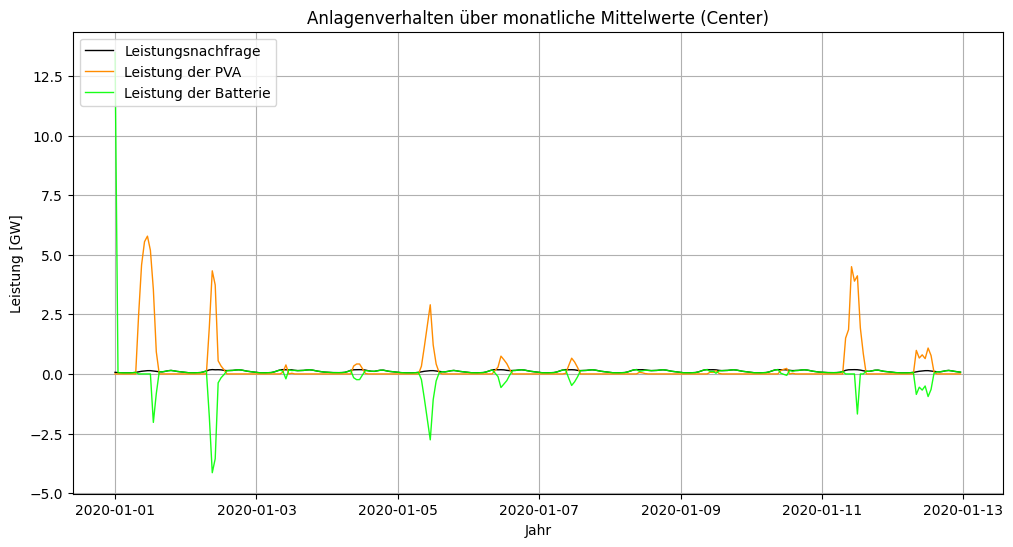

In [ ]:
# -- Visualisierung der Modellausgaben
df_result_for_visualization = df_result.loc[
    "2020-01-01 00:00:00":"2020-01-12 23:50:00", ("P_pva_model", "P_bat", "P_demand", "loss")
    ]#.resample("ME").mean()
# 2023-04-30
# df_result_for_visualization = df_result_for_visualization.groupby(df_result_for_visualization.index.time).mean()

x = df_result_for_visualization.index #[t.hour + t.minute / 60 for t in df_result_for_visualization.index] #
y_demand = df_result_for_visualization["P_demand"] / 1e9
y_pva = df_result_for_visualization["P_pva_model"] / 1e9
y_bat = df_result_for_visualization["P_bat"] / 1e9
y_loss = df_result_for_visualization["loss"] / 1e9
y_sum = y_pva - y_loss + y_bat 

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(x, y_demand, label="Leistungsnachfrage", linewidth=1, color="black", alpha=1)
ax1.plot(x, y_pva, label="Leistung der PVA", linewidth=1, color="darkorange", alpha=1)
ax1.plot(x, y_bat, label="Leistung der Batterie", linewidth=1, color="lime", alpha=0.9) 
ax1.set_ylabel("Leistung [GW]")
ax1.set_xlabel("Jahr") ######### Stunden
ax1.legend(loc="upper left")

# ax1.set_xticks([0, 4, 8, 12, 16, 20, 24]) #########

plt.grid(True)

plt.title(f"Anlagenverhalten über monatliche Mittelwerte ({list_str_location[i]})") # durchschnittlichen Tag
plt.show()